In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# 1. Carregar os dados
df = pd.read_csv("../data/train.csv", parse_dates=["date"])

In [3]:
# --- Pergunta 1: estrutura básica ---
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(913000, 4)
date     datetime64[us]
store             int64
item              int64
sales             int64
dtype: object
date     0
store    0
item     0
sales    0
dtype: int64


# Estrutura básica
Sem problemas de qualidade

In [4]:
# --- Pergunta 2: cobertura temporal ---
print(df["date"].min())
print(df["date"].max())
print(df["item"].nunique())
print(df["store"].nunique())

2013-01-01 00:00:00
2017-12-31 00:00:00
50
10


# Cobertura temporal
Dataset com 5 anos completos (2013–2017), 10 lojas × 50 itens (500 séries temporais distintas). Cinco anos é suficiente para capturar sazonalidade anual, e a estrutura multi-série exige que qualquer feature de lag/rolling seja calculada agrupando por loja-item, para não misturar séries diferentes.

In [5]:
# --- Pergunta 3: distribuição da variável alvo ---
print(df["sales"].describe())
print(df[df['sales'] < 0])

count    913000.000000
mean         52.250287
std          28.801144
min           0.000000
25%          30.000000
50%          47.000000
75%          70.000000
max         231.000000
Name: sales, dtype: float64
Empty DataFrame
Columns: [date, store, item, sales]
Index: []


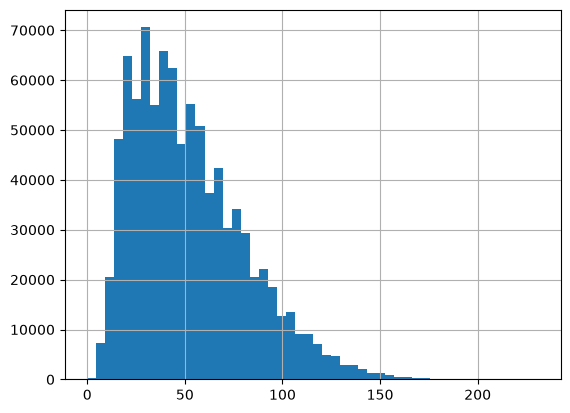

Skewness: 0.8671122960235801


In [6]:
# 3.1 Forma da distribuição -- é simétrica ou enviesada?
df["sales"].hist(bins=50)
plt.show()
print("Skewness:", df["sales"].skew())

In [7]:
# 3.2 Quantos dias têm venda zero?
pct_zeros = (df["sales"] == 0).mean() * 100
print(f"{pct_zeros:.2f}% dos dias têm venda zero")

0.00% dos dias têm venda zero


In [8]:
# 3. Outliers -- o valor máximo (231) é um erro de dado ou uma venda real muito alta?
print(df[df["sales"] == df["sales"].max()])

             date  store  item  sales
259109 2017-07-02      2    15    231


# Distribuição da variável alvo
É identificado que na maioria dos dias o volume de vendas é moderado mas existem dias com grandes volumes de vendas. Além de que não existem dias sem vendas, indicando se tratar de um negócio de demanda regular.

Outro ponto, é possível identificar um outlier da maior venda em um dia, que olhando as suas informações não demonstra ser um erro, pois é localizada no mês, no dia da semana e na loja com o maior volume de vendas.

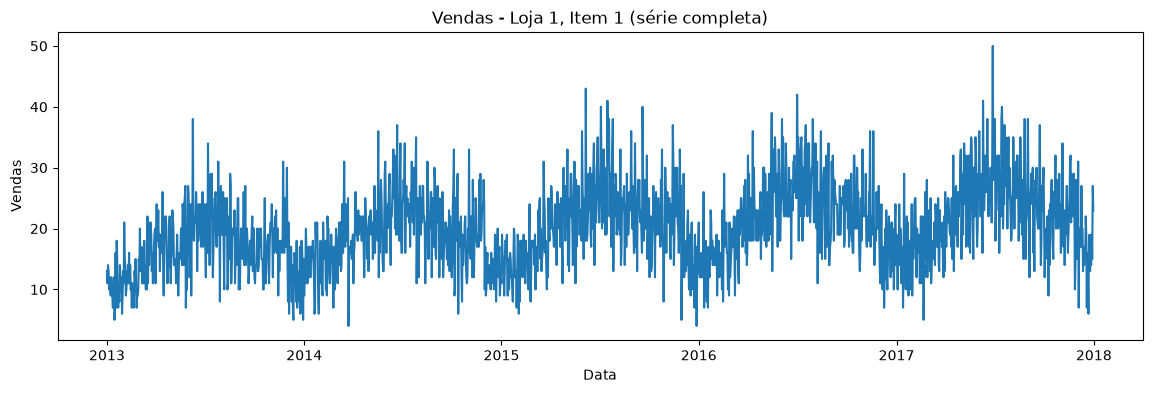

date
1     35.524503
2     39.378397
3     47.305574
4     55.152893
5     59.128219
6     63.025480
7     66.998619
8     59.105226
9     55.072760
10    51.193806
11    55.218080
12    39.365265
Name: sales, dtype: float64
year
2013    43.513660
2014    50.057436
2015    52.256915
2016    56.596503
2017    58.815014
Name: sales, dtype: float64


In [9]:
# --- Pergunta 4: padrão temporal ---
sample = df[(df["store"] == 1) & (df["item"] == 1)].sort_values("date")

plt.figure(figsize=(14, 4))
plt.plot(sample["date"], sample["sales"])
plt.title("Vendas - Loja 1, Item 1 (série completa)")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.show()

vendas_por_mes = df.groupby(df["date"].dt.month)["sales"].mean()
print(vendas_por_mes)

# --- Confirmar a tendência de crescimento ano a ano ---
df["year"] = df["date"].dt.year
vendas_por_ano = df.groupby("year")["sales"].mean()
print(vendas_por_ano)

# Padrão temporal
É possível perceber um padrão entre os anos que ao se aproximarem do meio do ano, especificamente durante julho, tem um maior volume de vendas, indicando um maior volume de vendas em período de fim de férias escolares. Além de um leve crescimento de vendas com o passar dos anos, mostrando que as mudanças ao longo dos anos foram positivas tendo um crescimento de ~35% na média de vendas entre 2013 e 2017, com desaceleração no ritmo de crescimento nos últimos anos, confirmando o que foi apresentado no gráfico.

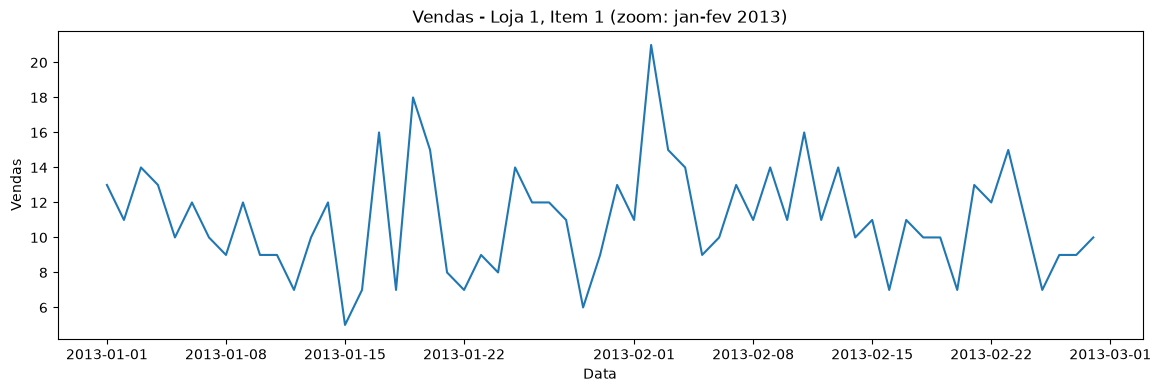

day_of_week
0    41.429638
1    48.225908
2    48.368506
3    51.723218
4    55.157249
5    58.662697
6    62.143333
Name: sales, dtype: float64


In [10]:
# Padrão semanal
zoom = sample[sample["date"] < "2013-03-01"]

plt.figure(figsize=(14, 4))
plt.plot(zoom["date"], zoom["sales"])
plt.title("Vendas - Loja 1, Item 1 (zoom: jan-fev 2013)")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.show()

# --- Confirmar o padrão semanal exato ---
df["day_of_week"] = df["date"].dt.dayofweek  # 0=segunda, 6=domingo
vendas_por_dia_semana = df.groupby("day_of_week")["sales"].mean()
print(vendas_por_dia_semana)

# Padrão semanal
É possível visualizar picos ao se aproximar do fim de uma semana, provavelmente pelo maior movimento de pessoas saindo durante a folga. Com os números é possível ter uma visão mais clara de que durante finais de semanas, especialmente no domingo, o volume de vendas é maior, reforçando a informação do gráfico.

In [11]:
# --- Pergunta 5: comparação entre lojas ---
vendas_por_loja = df.groupby("store")["sales"].mean()
print(vendas_por_loja.sort_values(ascending=False))

store
2     67.033165
8     64.142048
3     59.530602
10    58.709288
9     55.049025
4     54.902946
1     47.268379
5     39.770164
6     39.733516
7     36.363735
Name: sales, dtype: float64


In [12]:
vendas_por_loja_ano = df.groupby(["year", "store"])["sales"].mean().reset_index()
pivot = vendas_por_loja_ano.pivot(index="year", columns="store", values="sales")
print(pivot)

store         1          2          3          4          5          6   \
year                                                                      
2013   39.333699  55.903452  49.530740  45.756658  33.084000  33.116329   
2014   45.303342  64.208055  57.014795  52.559178  38.115014  38.093918   
2015   47.216986  66.968986  59.512493  54.944110  39.744767  39.776274   
2016   51.229126  72.651530  64.514699  59.464208  43.129563  42.967158   
2017   53.247890  75.418411  67.066630  61.778082  44.768274  44.705041   

store         7          8          9          10  
year                                               
2013   30.258795  53.405753  45.796603  48.950575  
2014   34.848110  61.473808  52.700219  56.257918  
2015   36.398192  64.166904  55.124438  58.716000  
2016   39.365137  69.436885  59.608251  63.598470  
2017   40.940219  72.212384  62.003123  66.010082  


# Comparação entre lojas
É possível observar que a loja 2 se mantém sempre com o maior volume de vendas e a loja 7 o menor, mostrando diferenças entre as estruturas das lojas. Também é possível ver que todas as lojas crescem juntas ano a ano, sugerindo que por mais que uma loja cresça ela não "rouba" clientes de outra loja, e sim o mercado inteiro que cresce a cada ano.